# Prosjekt for IMAx2022/IMAx2023/IMAx2024





# Hovedprosjekt:


## Del 1: Trafikkmodell: tetthet, hastighet og fluks


## Oppgave 1. (10 poeng) Mats

### a) Funksjonen $u(x,t)$

i) Hvis vi ser på grafen for et fast tidspunkt $t=t_0$, så viser den hvordan tettheten varierer langs veien akkurat da.

ii) Hvis vi i stedet holder $x=x_0$ fast, ser vi hvordan tettheten i det punktet endrer seg med tid.

iii) Når vi øker $R$, glatter vi i praksis ut dataene mer (snitt over et lengre stykke). Da blir grafen roligere. Med liten $R$ får vi mer detaljer, men også mer støy.

### b) Funksjonen $v=v(u)$

i) En naturlig antakelse er at $v(0)=v_{\max}$: når det nesten ikke er biler, kan man kjøre nær maks fart. Når tettheten blir maksimal ($u=u_{\max}$), stopper trafikken opp og da blir $v(u_{\max})=0$. Vi antar også at hastighet i kjøreretning ikke er negativ.

ii) Vi bruker modellen

$$
v(u)=v_{\max}\left(1-\left(\frac{u}{u_{\max}}\right)^p\right),\quad p\ge 1,\; 0\le u\le u_{\max}.
$$

**1. $v(u)\ge 0$**
Siden $0\le \frac{u}{u_{\max}}\le 1$ og $p\ge1$, så ligger $\left(\frac{u}{u_{\max}}\right)^p$ mellom 0 og 1. Dermed er faktoren i parentes ikke-negativ, og med $v_{\max}>0$ får vi $v(u)\ge0$.

**2. $v(u)\le v_{\max}$**
Vi har alltid $1-\left(\frac{u}{u_{\max}}\right)^p\le1$, derfor

$$
v(u)=v_{\max}\left(1-\left(\frac{u}{u_{\max}}\right)^p\right)\le v_{\max}.
$$

**3. $\frac{dv}{du}\le 0$**
Deriverer vi får vi

$$
\frac{dv}{du}=-\frac{v_{\max}p}{u_{\max}^p}u^{p-1}\le0
$$

for $u\in[0,u_{\max}]$. Det betyr at farten avtar når tettheten øker.

**4. $v(0)=v_{\max}$**
Setter vi $u=0$, får vi direkte $v(0)=v_{\max}$.

**5. $v(u_{\max})=0$**
Setter vi $u=u_{\max}$, får vi $v(u_{\max})=0$.

iii) Se graf i kodecellen under.

### c) De deriverte

i) Hastighetsfunksjonen er

$$
v(u)=v_{\max}\left(1-\left(\frac{u}{u_{\max}}\right)^p\right),
$$

og den deriverte blir

$$
v'(u)=-\frac{v_{\max}p}{u_{\max}^p}u^{p-1}.
$$

ii) Fluksen defineres som

$$
J(u)=u\,v(u)=v_{\max}\left(u-\frac{u^{p+1}}{u_{\max}^p}\right).
$$

Deriverer vi denne får vi

$$
J'(u)=v_{\max}\left(1-(p+1)\left(\frac{u}{u_{\max}}\right)^p\right).
$$

iii) Andrederivert av fluksen er

$$
J''(u)=-\frac{v_{\max}p(p+1)}{u_{\max}^p}u^{p-1}\le0,
$$

så $J(u)$ er konkav nedover på intervallet $[0,u_{\max}]$.

### d) Utregning av fluksen

Fluks forteller hvor mange biler som passerer et punkt per tidsenhet. I denne modellen blir det

$$
J(u)=u\,v(u).
$$

Setter vi inn uttrykket for $v(u)$, får vi

$$
J(u)=v_{\max}\left(u-\frac{u^{p+1}}{u_{\max}^p}\right).
$$

Denne funksjonen bruker vi videre for å finne maksimal gjennomstrømning.

### e) Maksimal fluks

i) Maksimum finner vi ved å sette $J'(u)=0$:

$$
1-(p+1)\left(\frac{u}{u_{\max}}\right)^p=0
\quad\Rightarrow\quad
u_*=u_{\max}\left(\frac{1}{p+1}\right)^{1/p}.
$$

Siden $J''(u)\le0$, er dette faktisk et maksimum.

ii) Tilhørende hastighet og maksimal fluks blir

$$
v(u_*)=v_{\max}\frac{p}{p+1},
$$

$$
J_{\max}=u_*v(u_*)
=v_{\max}u_{\max}\,\frac{p}{(p+1)^{1+1/p}}.
$$

For lineær modell ($p=1$) får vi spesialtilfellet $u_*=u_{\max}/2$ og $J_{\max}=v_{\max}u_{\max}/4$.

### f) Differensiallikningen

Trafikkmodellen følger en bevaringslov:

$$
\frac{\partial u}{\partial t}+\frac{\partial}{\partial x}\big(J(u)\big)=0,
$$

altså

$$
u_t+\big(u\,v(u)\big)_x=0.
$$

Setter vi inn hastighetsmodellen, får vi

$$
u_t+\frac{\partial}{\partial x}\left[v_{\max}u\left(1-\left(\frac{u}{u_{\max}}\right)^p\right)\right]=0.
$$

Skrevet på kvasilineær form:

$$
u_t+v_{\max}\left(1-(p+1)\left(\frac{u}{u_{\max}}\right)^p\right)u_x=0.
$$

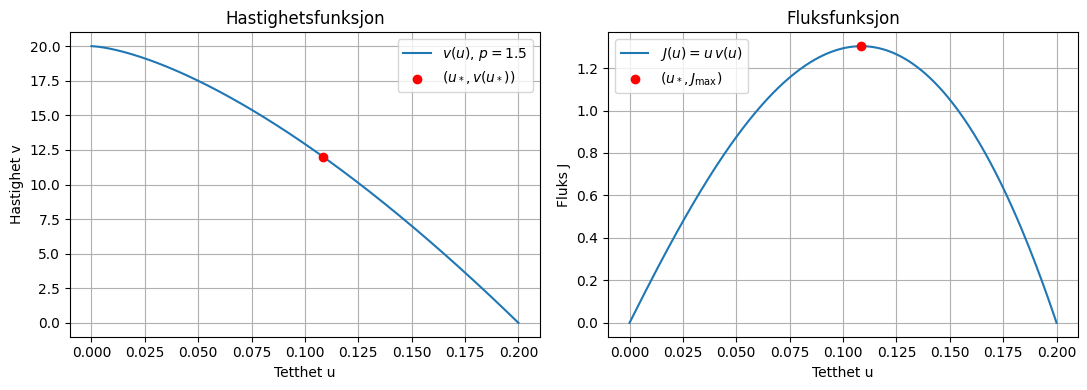

u* = 0.10858
v(u*) = 12.00000
J_max = 1.30292


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametre i modellen
v_max = 20
u_max = 0.2
p = 1.5

# Tetthet
u = np.linspace(0, u_max, 400)

# Hastighet og fluks
v = v_max * (1 - (u / u_max)**p)
J = u * v

# Teoretisk punkt for maksimal fluks
u_star = u_max * (1 / (p + 1))**(1 / p)
v_star = v_max * p / (p + 1)
J_star = u_star * v_star

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(u, v, label=fr'$v(u)$, $p={p}$')
ax1.scatter([u_star], [v_star], color='red', zorder=3, label=r'$(u_*, v(u_*))$')
ax1.set_xlabel('Tetthet u')
ax1.set_ylabel('Hastighet v')
ax1.set_title('Hastighetsfunksjon')
ax1.grid(True)
ax1.legend()

ax2.plot(u, J, label=r'$J(u)=u\,v(u)$')
ax2.scatter([u_star], [J_star], color='red', zorder=3, label=r'$(u_*, J_{\max})$')
ax2.set_xlabel('Tetthet u')
ax2.set_ylabel('Fluks J')
ax2.set_title('Fluksfunksjon')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print(f'u* = {u_star:.5f}')
print(f'v(u*) = {v_star:.5f}')
print(f'J_max = {J_star:.5f}')

### Oppgave 2. Rødt lys (15 poeng) Atle


### a) Initialverdibetingelsen
En naturlig initialbetingelse som beskriver situasjonen ved <<LATEX_2>> er

<<LATEX_3>>

Dette uttrykket sier at tettheten av biler er maksimal <<LATEX_4>> bak lyskrysset <<LATEX_5>>, siden alle bilene står og venter i kø, mens det ikke er noen biler foran lyskrysset <<LATEX_6>>, fordi lyset har vært rødt helt frem til <<LATEX_7>>.

### b) Verdiene $v_{max}$ og $u_{max}$ og randbetingelsen for $x=1000$.


### c) Løs differensiallikningen


### d) Bevegelsen til en enkelt bil


### e) Hastigheten til en kø


### f) Valg av parameter $p$



## Del 2: Varmeledning


## Oppgave 3: Poissonligning, 1D (5 poeng) David

### a)
![Utregning for oppgave 3a](IMG_4552.jpeg)

### b)
Bildet viser at løsningen blir lik numerisk og eksakt. Python programmet som ble brukt for å lage denne grafen ligger i code cellen under.
![Bilde av grafen løst numerisk og eksakt](oppg3b.png)





max error = 0.0004171812123154872


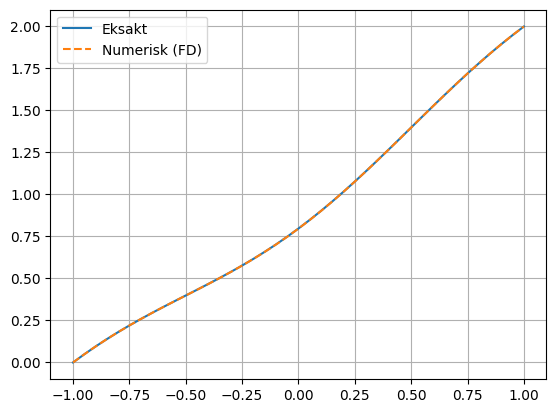

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def u_exact(x):
    return x + 1 - (1 + np.cos(np.pi*x))/np.pi**2

n = 40
a, b = -1, 1
h = (b-a)/n
x = np.linspace(a, b, n+1)


m = n-1
A = np.zeros((m, m))
rhs = (h**2) * np.cos(np.pi * x[1:-1])

uL, uR = 0.0, 2.0
rhs[0]  -= uL
rhs[-1] -= uR

for i in range(m):
    A[i, i] = -2
    if i > 0:     A[i, i-1] = 1
    if i < m-1:   A[i, i+1] = 1

u_inner = np.linalg.solve(A, rhs)

u_num = np.zeros(n+1)
u_num[0], u_num[-1] = uL, uR
u_num[1:-1] = u_inner

u_ex = u_exact(x)

print("max error =", np.max(np.abs(u_num - u_ex)))

plt.plot(x, u_ex, label="Eksakt")
plt.plot(x, u_num, "--", label="Numerisk (FD)")
plt.legend()
plt.grid(True)
plt.show()

## Oppgave 4: Varmeligning, 1D (5 poeng) Erik

## Oppgave 5: Poissonligning, 2D (5 poeng) - Nikolai

## Siden f = 0, er dette egentlig en laplace-ligning. Altså Uxx + #Uyy = 0. På rektangelet -5 < x < 5, 0 < y < 2. 

## Vi må også erstatte området vi skal løse ligningen på med et #rutenett for å løse den numerisk. Vi velger et antall intervaller #i x- og y-retning: Hx = 10/Nx, Hy = 2/Ny. Der N tilsvarer antall #punkter vi vil ha, og Hx og Hy er steglengden. 

## Gitterpunktene våre blir da Xi = -5 + i*Hx, I=0, …. , Nx
## Og Yi = 0 + j*Hy, J = 0,…..,Ny

## For å approksimere den deriverte bruker vi sentraldifferanse 
## Den andrederiverte i x blir: Uxx(Xi,Yj) =( U(i+1,j) – 2Uij + U(i-1,j) )/ (Hx)^2
## Den andrederiverte for y blir:  Uyy(Xi,Yj) = ( U(i,j+1) – 2 Uij + U(i,j-1) ) / (Hy)^2
## Disse setter vi inn i PDEen: ( ( U(i+1,j) – 2Uij + U(i-1,j) )/ (Hx)^2 ) +( U(i,j+1) – 2 Uij + U(i,j-1) ) / (Hy)^2 )= 0

## Hvis vi velger lik steglengde i begge retninger kan vi forenkle ligningen til:
## U(ij) = ¼ * (U(i+1,j) + U(i-1,j) + U(i,j+1) + U(i,j-1)

## Så bruker vi Gauss-seidel metoden for å løse ligningen numerisk
## New(u(ij)) = ¼ * (old((u(i+1,j)) + new(u(i-1,j)) + old(u(I,j+1)) + new(u(I,j-1))

![løsningsplott for oppgave 5](oppgave5.png)


## Oppgave 6: Varmeligning,  (10 poeng) -David +noen


### a)


### b)


### c)


### d)



## Oppgave 7: Luften skal med (10 poeng)



### a)


### b)


### c)



## Oppgave 8 (10 poeng)
## Grupppen har møtt opp ukentlig på ingeniørlabben for å arbeide med oppgavene. For å være så effektiv som mulig har gruppen valgt å dele opp oppgavene seg imellom. Dette førte til at gruppen fikk gjort flere oppgaver samtidig, som gjorde arbeidet mye raskere. For å holde styr på alt dette arbeidet som foregikk i samtid ble github tatt i bruk for versjonskontroll. Gruppen er som helhet veldig fornøyd med hvordan arbeidet har gått, og hvordan oppgaven har blitt løst.
